Temperature data from ERA5

In [14]:
import xarray as xr
import gcsfs

print("import done")


import done


In [15]:
fs = gcsfs.GCSFileSystem(token="anon")

mapper = fs.get_mapper(
    "weatherbench2/datasets/era5/1959-2023_01_10-full_37-1h-0p25deg-chunk-1.zarr"
)

era5 = xr.open_zarr(mapper, consolidated=True)

print(era5)

<xarray.Dataset> Size: 669TB
Dimensions:                                           (time: 561264,
                                                       latitude: 721,
                                                       longitude: 1440,
                                                       level: 37)
Coordinates:
  * time                                              (time) datetime64[ns] 4MB ...
  * latitude                                          (latitude) float32 3kB ...
  * longitude                                         (longitude) float32 6kB ...
  * level                                             (level) int64 296B 1 .....
Data variables: (12/48)
    10m_u_component_of_wind                           (time, latitude, longitude) float32 2TB ...
    10m_v_component_of_wind                           (time, latitude, longitude) float32 2TB ...
    2m_dewpoint_temperature                           (time, latitude, longitude) float32 2TB ...
    2m_temperature                 

In [16]:
print("Latitude:", era5.latitude.values[:5], "...", era5.latitude.values[-5:])
print("Longitude:", era5.longitude.values[:5], "...", era5.longitude.values[-5:])

Latitude: [90.   89.75 89.5  89.25 89.  ] ... [-89.   -89.25 -89.5  -89.75 -90.  ]
Longitude: [0.   0.25 0.5  0.75 1.  ] ... [358.75 359.   359.25 359.5  359.75]


In [17]:
maharashtra = era5["2m_temperature"].sel(
    latitude=slice(22, 15),
    longitude=slice(72, 81)
)

print(maharashtra)

<xarray.DataArray '2m_temperature' (time: 561264, latitude: 29, longitude: 37)> Size: 2GB
[602236272 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4MB 1959-01-01 ... 2023-01-10T23:00:00
  * latitude   (latitude) float32 116B 22.0 21.75 21.5 21.25 ... 15.5 15.25 15.0
  * longitude  (longitude) float32 148B 72.0 72.25 72.5 ... 80.5 80.75 81.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [18]:
day = maharashtra.sel(
    time=slice("2020-07-01", "2020-07-01T23:00:00")
)

print(day)

<xarray.DataArray '2m_temperature' (time: 24, latitude: 29, longitude: 37)> Size: 103kB
[25752 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 192B 2020-07-01 ... 2020-07-01T23:00:00
  * latitude   (latitude) float32 116B 22.0 21.75 21.5 21.25 ... 15.5 15.25 15.0
  * longitude  (longitude) float32 148B 72.0 72.25 72.5 ... 80.5 80.75 81.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [19]:
day_c = day.load() - 273.15

print(day_c)

<xarray.DataArray '2m_temperature' (time: 24, latitude: 29, longitude: 37)> Size: 103kB
array([[[30.192535, 29.279327, 29.74646 , ..., 24.901215, 24.6185  ,
         25.001343],
        [30.087158, 29.296906, 29.546265, ..., 25.136566, 24.832733,
         25.245453],
        [29.58316 , 29.267029, 28.613739, ..., 25.575592, 25.370117,
         25.74945 ],
        ...,
        [26.664398, 26.687256, 26.688995, ..., 28.27304 , 27.603973,
         27.092926],
        [26.769775, 26.57132 , 26.57309 , ..., 29.108978, 28.578644,
         27.7901  ],
        [26.73642 , 26.441376, 26.341278, ..., 29.063324, 28.9404  ,
         28.331024]],

       [[30.248749, 29.3443  , 29.58139 , ..., 24.867859, 24.61322 ,
         25.004852],
        [30.15567 , 29.389984, 29.449677, ..., 25.133026, 24.85205 ,
         25.27179 ],
        [29.468994, 29.238953, 28.627808, ..., 25.568573, 25.308655,
         25.6792  ],
...
        [27.426575, 27.352814, 27.092926, ..., 28.975525, 29.242462,
         29.31

In [20]:
print(day_c.min().item())
print(day_c.max().item())

21.71380615234375
36.48309326171875


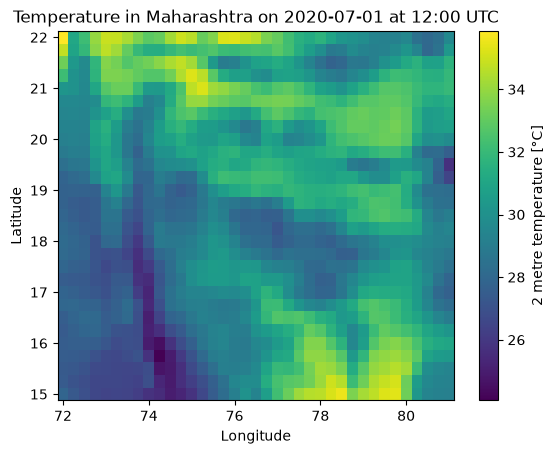

In [21]:
import matplotlib.pyplot as plt

day_c.attrs["units"] = "°C"

day_c.isel(time=12).plot()

plt.title("Temperature in Maharashtra on 2020-07-01 at 12:00 UTC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Terrian Data from Earth Engine

In [22]:
import ee

# ee.Authenticate()

In [23]:
ee.Initialize(project="alien-cedar-483108-h3")

In [24]:
srtm = ee.Image("USGS/SRTMGL1_003")

print(srtm.getInfo()["bands"][0]["id"])

elevation


In [25]:
point = ee.Geometry.Point([77, 19])

elevation_value = srtm.reduceRegion(reducer=ee.Reducer.first(), geometry=point, scale=30)
print("Elevation at point (77, 19):", elevation_value.getInfo())

Elevation at point (77, 19): {'elevation': 392}


In [26]:
region = ee.Geometry.Rectangle([76.9, 18.9, 77.0, 19.0])

print(region.getInfo())

{'type': 'Polygon', 'coordinates': [[[76.9, 18.9], [77, 18.9], [77, 19], [76.9, 19], [76.9, 18.9]]]}


In [27]:
# import requests

# response = requests.get(url)
# response.raise_for_status()

# with open("srtm_test.tif", "wb") as f:
#     f.write(response.content)

# print("Downloaded: ", len(response.content), "bytes")

In [28]:
import rasterio

with rasterio.open("srtm_test.tif") as src:
    print("Width:", src.width)
    print("Height:", src.height)
    print("Resolution:", src.res)
    print("CRS:", src.crs)

Width: 113
Height: 112
Resolution: (0.0008983152841195214, 0.0008983152841195214)
CRS: EPSG:4326


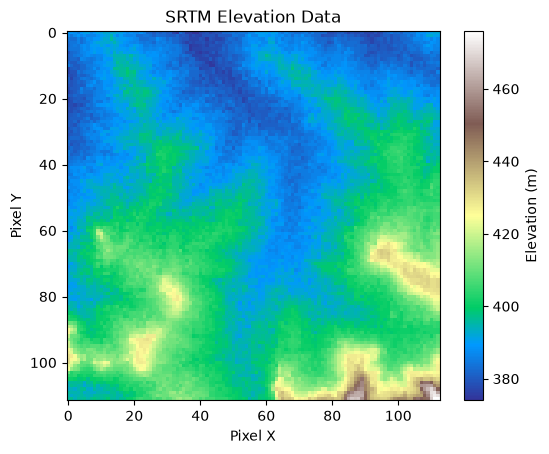

In [29]:
import matplotlib.pyplot as plt

with rasterio.open("srtm_test.tif") as src:
    elevation_data = src.read(1)
plt.imshow(elevation_data, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('SRTM Elevation Data')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()

In [30]:
from pyproj import Transformer

# WGS84 -> UTM ZONE 43N
to_utm = Transformer.from_crs("EPSG:4326", "EPSG:32643", always_xy=True)

# convert the four corners into meters
corners = [
    (76.9, 18.9),
    (77.0, 18.9),
    (77.0, 19.0),
    (76.9, 19.0)
]
utm_corners = [to_utm.transform(lon, lat) for lon, lat in corners]
for corner in utm_corners:
    print(corner)


(700123.1297139821, 2090837.8228832113)
(710659.2449421217, 2090954.020561114)
(710533.7064424448, 2102024.0974453366)
(700003.8785698314, 2101907.3773003933)


In [32]:
import numpy as np
xs = [p[0] for p in utm_corners]
ys = [p[1] for p in utm_corners]

width = max(xs) - min(xs)
height = max(ys) - min(ys)

cell_size = 2000

n_cols = int(np.ceil(width / cell_size))
n_rows = int(np.ceil(height / cell_size))

print("Width:", width, "m")
print("Height:", height, "m")
print("Columns:", n_cols)
print("Rows:", n_rows)
print("Total cells:", n_cols * n_rows)

Width: 10655.3663722903 m
Height: 11186.274562125327 m
Columns: 6
Rows: 6
Total cells: 36


In [33]:
grid_cells = []

min_x = min(xs)
max_y = max(ys)

for row in range(n_rows):
    for col in range(n_cols):
        x_min = min_x + col * cell_size
        x_max = x_min + cell_size

        y_max = max_y - row * cell_size
        y_min = y_max - cell_size

        grid_cells.append((x_min, y_min, x_max, y_max))

print("Created cells:", len(grid_cells))
print("First cell:", grid_cells[0])

Created cells: 36
First cell: (700003.8785698314, 2100024.0974453366, 702003.8785698314, 2102024.0974453366)


In [34]:
from pyproj import Transformer

to_wgs84 = Transformer.from_crs("EPSG:32643", "EPSG:4326", always_xy=True)
grid_cells_wgs84 = []

for x_min, y_min, x_max, y_max in grid_cells:
    lon_min, lat_min = to_wgs84.transform(x_min, y_min)
    lon_max, lat_min = to_wgs84.transform(x_max, y_max)

    grid_cells_wgs84.append((lon_min, lat_min, lon_max, lat_min))

print("First cell in WGS84:", grid_cells_wgs84[0])

First cell in WGS84: (76.89980695596329, 19.000858200331923, 76.91900386539467, 19.000858200331923)


In [35]:
x_min, y_min, x_max, y_max = grid_cells[0]

corners_utm = [
    (x_min, y_min),
    (x_max, y_min),
    (x_max, y_max),
    (x_min, y_max)
]

corners_wgs84 = [
    to_wgs84.transform(x, y)
    for x, y in corners_utm
]

print("First cell corners:")
for corner in corners_wgs84:
    print(corner)

First cell corners:
(76.89980695596329, 18.98298889970025)
(76.91879680407149, 18.982793003485565)
(76.91900386539467, 19.000858200331923)
(76.9000119710731, 19.00105429686088)


In [36]:
grid_features = []

for corners in [
    [
        to_wgs84.transform(x_min, y_min),
        to_wgs84.transform(x_max, y_min),
        to_wgs84.transform(x_max, y_max),
        to_wgs84.transform(x_min, y_max)
    ]
    for x_min, y_min, x_max, y_max in grid_cells
]:
    coords = [[lon, lat] for lon, lat in corners]
    coords.append(coords[0])

    polygon = ee.Geometry.Polygon([coords])

    grid_features.append(
        ee.Feature(polygon)
    )

grid = ee.FeatureCollection(grid_features)

print("Earth Engine grid cells:", grid.size().getInfo())

Earth Engine grid cells: 36


In [37]:
grid_elevation = srtm.reduceRegions(
    collection=grid,
    reducer=ee.Reducer.mean(),
    scale=30
)

print("Cells:", grid_elevation.size().getInfo())

Cells: 36


In [38]:
elevation_data = grid_elevation.getInfo()
print(elevation_data["features"][0]["properties"])

{'mean': 388.64350374173546}


In [39]:
import pandas as pd

elevation_rows = []

for i, feature in enumerate(elevation_data["features"]):
    elevation_rows.append({
        "cell_id" : i,
        "mean_elevation": feature["properties"]["mean"]
    })

elevation_df = pd.DataFrame(elevation_rows)
print(elevation_df.head())

   cell_id  mean_elevation
0        0      388.643504
1        1      384.065976
2        2      384.023913
3        3      388.739915
4        4      384.429831


In [40]:
print(elevation_df.describe())

         cell_id  mean_elevation
count  36.000000       36.000000
mean   17.500000      400.969472
std    10.535654       16.106561
min     0.000000      384.023913
25%     8.750000      388.715812
50%    17.500000      396.624546
75%    26.250000      405.314435
max    35.000000      454.654414


In [41]:
elevation_df = elevation_df.rename(
    columns={"mean_elevation": "mean_elevation_m"}
)

print(elevation_df.head())

   cell_id  mean_elevation_m
0        0        388.643504
1        1        384.065976
2        2        384.023913
3        3        388.739915
4        4        384.429831


Loading temperature from ERA5 of 2km grids as extracted for terrain

In [42]:
era5_test = era5["2m_temperature"].sel(
    latitude=slice(19.01, 18.89),
    longitude=slice(76.89, 77.01)
)

print(era5_test)

<xarray.DataArray '2m_temperature' (time: 561264, latitude: 1, longitude: 1)> Size: 2MB
[561264 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4MB 1959-01-01 ... 2023-01-10T23:00:00
  * latitude   (latitude) float32 4B 19.0
  * longitude  (longitude) float32 4B 77.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [43]:
era5_point = era5["2m_temperature"].sel(
    latitude=19.0,
    longitude=77.0
)

day = era5_point.sel(
    time=slice("2020-07-01", "2020-07-01T23:00:00")
)

day_c = day.load() - 273.15

print(day_c)


<xarray.DataArray '2m_temperature' (time: 24)> Size: 96B
array([25.521149, 25.398224, 26.07962 , 26.632812, 26.360596, 28.784088,
       29.83078 , 29.728912, 31.855621, 32.245483, 30.88095 , 31.416595,
       31.500885, 29.83429 , 28.910553, 27.723389, 27.965729, 27.481018,
       27.407257, 26.989288, 25.967224, 25.84253 , 25.42807 , 25.493042],
      dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 192B 2020-07-01 ... 2020-07-01T23:00:00
    latitude   float32 4B 19.0
    longitude  float32 4B 77.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [44]:
day_c.attrs["units"] = "°C"

print("Minimum:", float(day_c.min()), "°C")
print("Maximum:", float(day_c.max()), "°C")
print("Mean:", float(day_c.mean()), "°C")

Minimum: 25.398223876953125 °C
Maximum: 32.2454833984375 °C
Mean: 28.136587142944336 °C


In [45]:
print("Number of target cells:", len(grid_cells))
print("ERA5 grid point:", float(era5_point.latitude), float(era5_point.longitude))

Number of target cells: 36
ERA5 grid point: 19.0 77.0


In [46]:
hourly_df = pd.DataFrame({
    "time": day_c.time.values,
    "era5_temp_c": day_c.values
})

print(hourly_df)

                  time  era5_temp_c
0  2020-07-01 00:00:00    25.521149
1  2020-07-01 01:00:00    25.398224
2  2020-07-01 02:00:00    26.079620
3  2020-07-01 03:00:00    26.632812
4  2020-07-01 04:00:00    26.360596
5  2020-07-01 05:00:00    28.784088
6  2020-07-01 06:00:00    29.830780
7  2020-07-01 07:00:00    29.728912
8  2020-07-01 08:00:00    31.855621
9  2020-07-01 09:00:00    32.245483
10 2020-07-01 10:00:00    30.880951
11 2020-07-01 11:00:00    31.416595
12 2020-07-01 12:00:00    31.500885
13 2020-07-01 13:00:00    29.834290
14 2020-07-01 14:00:00    28.910553
15 2020-07-01 15:00:00    27.723389
16 2020-07-01 16:00:00    27.965729
17 2020-07-01 17:00:00    27.481018
18 2020-07-01 18:00:00    27.407257
19 2020-07-01 19:00:00    26.989288
20 2020-07-01 20:00:00    25.967224
21 2020-07-01 21:00:00    25.842529
22 2020-07-01 22:00:00    25.428070
23 2020-07-01 23:00:00    25.493042


In [47]:
target_hourly_df = (
    elevation_df
    .assign(key=1)
    .merge(
        hourly_df.assign(key=1),
        on="key"
    )
    .drop(columns="key")
)

print(target_hourly_df)
print("Number of rows:", len(target_hourly_df))

     cell_id  mean_elevation_m                time  era5_temp_c
0          0        388.643504 2020-07-01 00:00:00    25.521149
1          0        388.643504 2020-07-01 01:00:00    25.398224
2          0        388.643504 2020-07-01 02:00:00    26.079620
3          0        388.643504 2020-07-01 03:00:00    26.632812
4          0        388.643504 2020-07-01 04:00:00    26.360596
..       ...               ...                 ...          ...
859       35        454.654414 2020-07-01 19:00:00    26.989288
860       35        454.654414 2020-07-01 20:00:00    25.967224
861       35        454.654414 2020-07-01 21:00:00    25.842529
862       35        454.654414 2020-07-01 22:00:00    25.428070
863       35        454.654414 2020-07-01 23:00:00    25.493042

[864 rows x 4 columns]
Number of rows: 864


In [48]:
from pathlib import Path

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

In [ ]:
target_hourly_df.to_csv(
    "../data/processed/test_hourly_grid.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [49]:
from pyproj import Transformer

to_wgs84 = Transformer.from_crs(
    "EPSG:32643",
    "EPSG:4326",
    always_xy=True
)

cell_coordinates = []

for x_min, y_min, x_max, y_max in grid_cells:
    corners = [
        (x_min, y_min),
        (x_max, y_min),
        (x_max, y_max),
        (x_min, y_max)
    ]

    corners_wgs84 = [
        to_wgs84.transform(x, y)
        for x, y in corners
    ]

    lons = [p[0] for p in corners_wgs84]
    lats = [p[1] for p in corners_wgs84]

    cell_coordinates.append({
        "latitude": np.mean(lats),
        "longitude": np.mean(lons)
    })

coordinates_df = pd.DataFrame(cell_coordinates)

target_hourly_df[["latitude", "longitude"]] = (
    target_hourly_df["cell_id"]
    .map(coordinates_df.to_dict("index"))
    .apply(pd.Series)
)

print(target_hourly_df.head())

   cell_id  mean_elevation_m                time  era5_temp_c   latitude  \
0        0        388.643504 2020-07-01 00:00:00    25.521149  18.991924   
1        0        388.643504 2020-07-01 01:00:00    25.398224  18.991924   
2        0        388.643504 2020-07-01 02:00:00    26.079620  18.991924   
3        0        388.643504 2020-07-01 03:00:00    26.632812  18.991924   
4        0        388.643504 2020-07-01 04:00:00    26.360596  18.991924   

   longitude  
0  76.909405  
1  76.909405  
2  76.909405  
3  76.909405  
4  76.909405  


In [ ]:
# target_hourly_df.to_csv(
#     "../data/processed/test_hourly_grid.csv",
#     index=False
# )

# print("Updated dataset saved!")
# print("Rows:", len(target_hourly_df))
# print("Columns:", list(target_hourly_df.columns))

Updated dataset saved!
Rows: 864
Columns: ['cell_id', 'mean_elevation_m', 'time', 'era5_temp_c', 'latitude', 'longitude']


In [50]:
import requests

url = "https://www.ncei.noaa.gov/pub/data/ghcn/daily/ghcnd-inventory.txt"

response = requests.get(url)
response.raise_for_status()

print(response.text[:1000])

ACW00011604  17.1167  -61.7833 TMAX 1949 1949
ACW00011604  17.1167  -61.7833 TMIN 1949 1949
ACW00011604  17.1167  -61.7833 PRCP 1949 1949
ACW00011604  17.1167  -61.7833 SNOW 1949 1949
ACW00011604  17.1167  -61.7833 SNWD 1949 1949
ACW00011604  17.1167  -61.7833 PGTM 1949 1949
ACW00011604  17.1167  -61.7833 WDFG 1949 1949
ACW00011604  17.1167  -61.7833 WSFG 1949 1949
ACW00011604  17.1167  -61.7833 WT03 1949 1949
ACW00011604  17.1167  -61.7833 WT08 1949 1949
ACW00011604  17.1167  -61.7833 WT16 1949 1949
ACW00011647  17.1333  -61.7833 TMAX 1961 2026
ACW00011647  17.1333  -61.7833 TMIN 1961 2026
ACW00011647  17.1333  -61.7833 PRCP 1957 1970
ACW00011647  17.1333  -61.7833 SNOW 1957 1970
ACW00011647  17.1333  -61.7833 SNWD 1957 1970
ACW00011647  17.1333  -61.7833 TAVG 2025 2026
ACW00011647  17.1333  -61.7833 WT03 1961 1961
ACW00011647  17.1333  -61.7833 WT16 1961 1966
AE000041196  25.3330   55.5170 TMAX 1944 2025
AE000041196  25.3330   55.5170 TMIN 1944 2025
AE000041196  25.3330   55.5170 PRC

In [51]:
lines = response.text.splitlines()

pune_candidates = []

for line in lines:
    parts = line.split()

    if len(parts) >= 6:
        station = parts[0]
        lat = float(parts[1])
        lon = float(parts[2])
        element = parts[3]
        start_year = int(parts[4])
        end_year = int(parts[5])

        if 18.3 <= lat <= 18.7 and 73.6 <= lon <= 74.1:
            pune_candidates.append(
                (station, lat, lon, element, start_year, end_year)
            )

for row in pune_candidates:
    print(row)

('IN012190100', 18.533, 73.85, 'TMAX', 1957, 2025)
('IN012190100', 18.533, 73.85, 'TMIN', 1957, 2025)
('IN012190100', 18.533, 73.85, 'PRCP', 1901, 2025)
('IN012190100', 18.533, 73.85, 'TAVG', 1957, 2025)
('IN012190201', 18.53, 73.62, 'PRCP', 1901, 1970)
('IN012190301', 18.35, 74.03, 'PRCP', 1901, 1970)
('IN012190600', 18.67, 73.88, 'PRCP', 1901, 1964)
('IN012191600', 18.3, 73.63, 'PRCP', 1955, 1970)
('IN012191800', 18.5, 73.9, 'PRCP', 1951, 1970)


In [52]:
nearby_stations = []

for line in lines:
    parts = line.split()

    if len(parts) >= 6:
        station = parts[0]
        lat = float(parts[1])
        lon = float(parts[2])
        element = parts[3]
        start_year = int(parts[4])
        end_year = int(parts[5])

        if (
            18.65 <= lat <= 19.25
            and 76.65 <= lon <= 77.25
            and element in ["TMAX", "TMIN", "TAVG"]
        ):
            nearby_stations.append(
                (station, lat, lon, element, start_year, end_year)
            )

for row in nearby_stations:
    print(row)

('IN012180300', 19.133, 76.833, 'TMAX', 2016, 2026)
('IN012180300', 19.133, 76.833, 'TMIN', 2016, 2026)
('IN012180300', 19.133, 76.833, 'TAVG', 2016, 2026)


In [53]:
station_id = "IN012180300"

station_lines = [
    line for line in lines
    if line.startswith(station_id)
]

for line in station_lines:
    print(line)

IN012180300  19.1330   76.8330 TMAX 2016 2026
IN012180300  19.1330   76.8330 TMIN 2016 2026
IN012180300  19.1330   76.8330 PRCP 1913 2019
IN012180300  19.1330   76.8330 SNWD 2026 2026
IN012180300  19.1330   76.8330 TAVG 2016 2026


In [54]:
station_id = "IN012180300"

station_url = (
    f"https://www.ncei.noaa.gov/pub/data/ghcn/daily/"
    f"all/{station_id}.dly"
)

station_response = requests.get(station_url)
station_response.raise_for_status()

print("Downloaded:", len(station_response.content), "bytes")
print(station_response.text[:1000])

Downloaded: 201690 bytes
IN012180300191305PRCP    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I  417  I    0  I    0  I   13  I    0  I    0  I    0  I    0  I
IN012180300191306PRCP    0  I    0  I    0  I    0  I   41  I   61  I   79  I    0  I    0  I    0  I   58  I    0  I   25  I    0  I   28  I    0  I    0  I    0  I    0  I    0  I    0  I  597  I  876  I   48  I    8  I   30  I   97  I    0  I   46  I   15  I-9999   
IN012180300191307PRCP   61  I   53  I  434  I   23  I   20  I  180  I   13  I  198  I  241  I   69  I    0  I    0  I    0  I    0  I  117  I  155  I  429  I  627  I  417  I    0  I   10  I    0  I   13  I   20  I   94  I  437  I    8  I    0  I    8  I    0  I    0  I
IN012180300191308PRCP  145  I   69  I    5  I    0  I   36  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I    0  I

In [56]:
text = station_response.text

In [57]:
tavg_lines = [
    line for line in text.splitlines()
    if line[17:21] == "TAVG"
]

print("TAVG lines found:", len(tavg_lines))

for line in tavg_lines[:3]:
    print(line)

TAVG lines found: 20
IN012180300201610TAVG-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999     286H S-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   
IN012180300201704TAVG-9999   -9999     351H S-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   
IN012180300201907TAVG-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999     238H S-9999   


In [58]:
tavg_2020 = [
    line for line in text.splitlines()
    if line[11:15] == "2020"
    and line[17:21] == "TAVG"
]

print("Number of 2020 TAVG records:", len(tavg_2020))

for line in tavg_2020:
    print(line)

Number of 2020 TAVG records: 2
IN012180300202002TAVG-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999     280H S-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   
IN012180300202012TAVG-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999     226H S-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   


In [59]:
tmax_tmin_2020 = [
    line for line in text.splitlines()
    if line[11:15] == "2020"
    and line[17:21] in ["TMAX", "TMIN"]
]

for line in tmax_tmin_2020:
    print(line)

IN012180300202002TMIN-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999     164  S-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   
IN012180300202012TMAX-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999     301  S-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   
IN012180300202012TMIN-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999      96  S-9999   -9999   -9999   -9999   -9999   -9999   -9999   -9999   


In [60]:
import pandas as pd

valid_tmax_tmin = []

for line in text.splitlines():
    if line[17:21] in ["TMAX", "TMIN"]:
        year = int(line[11:15])

        # Extract the 31 daily values
        values = []
        for i in range(31):
            value = int(line[21 + i*8 : 26 + i*8])
            if value != -9999:
                values.append(value)

        if values:
            valid_tmax_tmin.append({
                "year": year,
                "element": line[17:21],
                "valid_days": len(values)
            })

valid_df = pd.DataFrame(valid_tmax_tmin)

valid_df.groupby(["year", "element"])["valid_days"].sum()

year  element
2016  TMAX         1
      TMIN         1
2017  TMAX         1
      TMIN         1
2019  TMIN         1
2020  TMAX         1
      TMIN         2
2021  TMAX         2
      TMIN         4
2022  TMAX         1
      TMIN         2
2023  TMAX         1
      TMIN         1
2024  TMAX         1
      TMIN         1
2025  TMAX        94
      TMIN       124
Name: valid_days, dtype: int64

In [61]:
import pandas as pd

csv_path = r"D:\AgroMet\data\raw\maha_temp_raw.csv"

station_info = {}

for chunk in pd.read_csv(csv_path, chunksize=50_000):
    for _, row in chunk.iterrows():
        station = row["Station"]

        if station not in station_info:
            station_info[station] = {
                "district": row["District"],
                "latitude": row["Latitude"],
                "longitude": row["Longitude"]
            }

station_df = pd.DataFrame.from_dict(
    station_info,
    orient="index"
).reset_index()

station_df = station_df.rename(columns={"index": "Station"})

print("Number of unique stations:", len(station_df))
display(station_df)

Number of unique stations: 94


,Station,district,latitude,longitude
0,Yeldari dam_1,Parbhani,19.715278,76.720833
1,Wangi_2,Sangli,17.236389,74.425000
2,Urmodi(Parali),Satara,17.661667,73.914167
3,Upper Pus_1,Yavatmal,19.991111,77.458889
4,Umbre (Kasurdi),Pune,18.200000,73.911111
...,...,...,...,...
89,Aurangpur,Akola,20.821111,77.540833
90,Aurangabad_3,Aurangabad,19.870000,75.290833
91,Aurad_3,Latur,18.076667,76.919167
92,Ashti_1,Solapur,17.843333,75.408611


In [62]:
station_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Station    94 non-null     str    
 1   district   94 non-null     str    
 2   latitude   94 non-null     float64
 3   longitude  94 non-null     float64
dtypes: float64(2), str(2)
memory usage: 3.1 KB


In [63]:
coverage = []

for chunk in pd.read_csv(
    csv_path,
    chunksize=50_000,
    usecols=[
        "Station",
        "Data Acquisition Time",
        "Air Temperature Telemetry Hourly (AoC)"
    ]
):
    chunk["Data Acquisition Time"] = pd.to_datetime(
        chunk["Data Acquisition Time"],
        dayfirst=True,
        errors="coerce"
    )

    # Treat blank/invalid temperature values as missing
    chunk["temperature"] = pd.to_numeric(
        chunk["Air Temperature Telemetry Hourly (AoC)"],
        errors="coerce"
    )

    summary = chunk.groupby("Station").agg(
        observations=("temperature", "size"),
        valid_temperature=("temperature", "count"),
        start_time=("Data Acquisition Time", "min"),
        end_time=("Data Acquisition Time", "max")
    )

    coverage.append(summary)

coverage_df = pd.concat(coverage).groupby(level=0).agg(
    observations=("observations", "sum"),
    valid_temperature=("valid_temperature", "sum"),
    start_time=("start_time", "min"),
    end_time=("end_time", "max")
)

coverage_df["missing_percentage"] = (
    1 - coverage_df["valid_temperature"] / coverage_df["observations"]
) * 100

coverage_df = coverage_df.sort_values(
    "valid_temperature",
    ascending=False
)

display(coverage_df)

,observations,valid_temperature,start_time,end_time,missing_percentage
Station,,,,,
Sarud,79019,79019,2022-02-12 14:15:00,2024-12-18 17:00:00,0.0
Barhanpur,76273,76273,2022-08-06 07:00:00,2024-12-18 17:00:00,0.0
Nazare_1,74548,74548,2022-02-12 14:30:00,2024-12-18 17:00:00,0.0
Umbre (Kasurdi),74402,74402,2022-02-24 23:15:00,2024-12-18 17:00:00,0.0
Rahimatpur,68592,68592,2021-05-22 14:30:00,2024-12-18 17:00:00,0.0
...,...,...,...,...,...
Birwadi_1,15436,15436,2024-01-24 16:00:00,2025-12-31 23:00:00,0.0
Padali_1,14281,14281,2024-02-06 12:00:00,2025-12-31 23:00:00,0.0
Sangamner (Ghulewadi),13143,13143,2024-03-21 19:00:00,2025-12-31 23:00:00,0.0


In [64]:
station_map_df = station_df.merge(coverage_df, left_on = "Station", right_index=True, how="left")
display(station_map_df)

,Station,district,latitude,longitude,observations,valid_temperature,start_time,end_time,missing_percentage
0,Yeldari dam_1,Parbhani,19.715278,76.720833,22524,22524,2023-07-09 19:00:00,2025-12-31 23:00:00,0.0
1,Wangi_2,Sangli,17.236389,74.425000,18964,18964,2022-02-12 15:30:00,2024-12-18 17:00:00,0.0
2,Urmodi(Parali),Satara,17.661667,73.914167,54910,54910,2022-02-12 14:00:00,2024-12-18 17:00:00,0.0
3,Upper Pus_1,Yavatmal,19.991111,77.458889,24732,24732,2023-05-07 20:00:00,2025-12-31 23:00:00,0.0
4,Umbre (Kasurdi),Pune,18.200000,73.911111,74402,74402,2022-02-24 23:15:00,2024-12-18 17:00:00,0.0
...,...,...,...,...,...,...,...,...,...
89,Aurangpur,Akola,20.821111,77.540833,29396,29396,2021-06-02 16:45:00,2025-12-31 23:00:00,0.0
90,Aurangabad_3,Aurangabad,19.870000,75.290833,18640,18640,2023-07-18 13:45:00,2025-12-31 23:00:00,0.0
91,Aurad_3,Latur,18.076667,76.919167,23298,23298,2023-07-15 11:15:00,2025-12-31 23:00:00,0.0
92,Ashti_1,Solapur,17.843333,75.408611,16273,16273,2022-02-12 14:30:00,2024-12-18 16:00:00,0.0


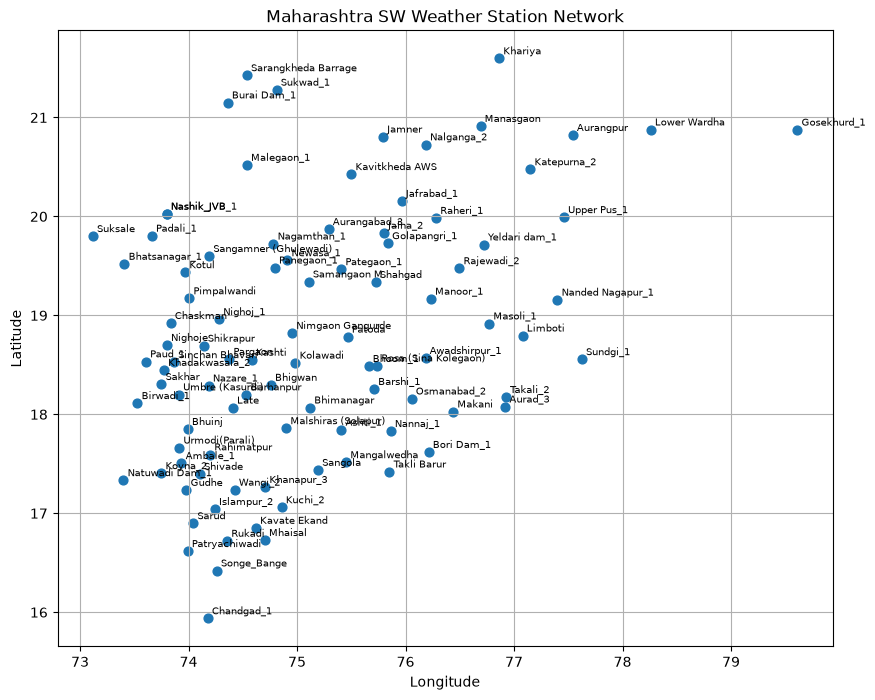

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    station_map_df["longitude"],
    station_map_df["latitude"],
    s=40
)

for _, row in station_map_df.iterrows():
    plt.annotate(
        row["Station"],
        (row["longitude"], row["latitude"]),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Maharashtra SW Weather Station Network")
plt.grid(True)

plt.show()

In [66]:
import sklearn
from sklearn.neighbors import NearestNeighbors
import numpy as np

coords = station_map_df[
    ["latitude", "longitude"]
].to_numpy()

# Convert latitude/longitude approximately to kilometres
coords_km = coords.copy()
coords_km[:, 0] *= 111
coords_km[:, 1] *= 111 * np.cos(np.radians(coords[:, 0]))

nn = NearestNeighbors(n_neighbors=2)
nn.fit(coords_km)

distances, indices = nn.kneighbors(coords_km)

station_map_df["nearest_station_km"] = distances[:, 1]

print(
    station_map_df["nearest_station_km"].describe()
)

count     94.000000
mean      31.690360
std       19.003358
min        0.000000
25%       21.849834
50%       28.303144
75%       40.319200
max      140.276617
Name: nearest_station_km, dtype: float64


In [67]:
station = station_map_df[
    station_map_df["Station"] == "Aurad_3"
].iloc[0]

print(station)

Station                           Aurad_3
district                            Latur
latitude                        18.076667
longitude                       76.919167
observations                        23298
valid_temperature                   23298
start_time            2023-07-15 11:15:00
end_time              2025-12-31 23:00:00
missing_percentage                    0.0
nearest_station_km              11.371845
Name: 91, dtype: object


In [68]:
station_lat = station["latitude"]
station_lon = station["longitude"]

era5_station = era5["2m_temperature"].sel(
    latitude=station_lat,
    longitude=station_lon,
    method="nearest"
)

print(era5_station)

<xarray.DataArray '2m_temperature' (time: 561264)> Size: 2MB
[561264 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4MB 1959-01-01 ... 2023-01-10T23:00:00
    latitude   float32 4B 18.0
    longitude  float32 4B 77.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K
